##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
%pip install --only-binary=:all: opencv-python-headless

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install -q keras-cv tensorflow matplotlib pillow requests

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

import tensorflow as tf
import keras
import keras_cv

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

2026-05-17 01:57:55.286108: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.16.2
Keras: 3.10.0
KerasCV: 0.9.0


In [3]:

model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",   
    bounding_box_format="xywh"
)

print("Model loaded successfully.")

Model loaded successfully.


In [4]:
image_urls = [

"https://images.unsplash.com/photo-1503376780353-7e6692767b70",  # car
"https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d",  # person
"https://images.unsplash.com/photo-1544620347-c4fd4a3d5957",     # bus
"https://images.unsplash.com/photo-1507035895480-2b3156c31fc8",   # bicycle
"https://images.unsplash.com/photo-1517423440428-a5a00ad493e8"  # dog


]
def load_image_from_url(url):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return np.array(image)

images = [load_image_from_url(url) for url in image_urls]

print("Number of images:", len(images))
print("Sample image shape:", images[0].shape)

Number of images: 5
Sample image shape: (2473, 3709, 3)


In [5]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [6]:
def preprocess_image(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = inference_resizing(image)
    image = tf.cast(image, tf.uint8)
    return image

In [7]:
def predict_image(model, image):
    resized = preprocess_image(image)
    batch = tf.expand_dims(resized, axis=0)  
    
    predictions = model.predict(batch, verbose=0)
    return resized, predictions

In [8]:
voc_classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

def visualize_predictions(image, predictions):

    image_batch = tf.expand_dims(image, axis=0)

    keras_cv.visualization.plot_bounding_box_gallery(
        image_batch,
        value_range=(0, 255),
        rows=1,
        cols=1,
        y_pred=predictions,
        scale=5,
        font_scale=0.7,
        bounding_box_format="xywh",
        class_mapping={i: name for i, name in enumerate(voc_classes)},
    )

In [9]:
def summarize_predictions(predictions, confidence_threshold=0.3):
    boxes = predictions["boxes"][0]
    classes = predictions["classes"][0]
    confidences = predictions["confidence"][0]

    results = []
    for box, cls_id, score in zip(boxes, classes, confidences):
        if score >= confidence_threshold:
            cls_id = int(cls_id)
            label = voc_classes[cls_id] if 0 <= cls_id < len(voc_classes) else f"class_{cls_id}"
            results.append({
                "label": label,
                "confidence": float(score),
                "box_xywh": box.tolist()
            })
    return results

Image 1
Detected objects:
- car | confidence = 0.988
Image 2
Detected objects:
- person | confidence = 0.964
Image 3
Detected objects:
- bus | confidence = 0.990
Image 4
Detected objects:
- bicycle | confidence = 0.989
Image 5
Detected objects:
- dog | confidence = 0.984


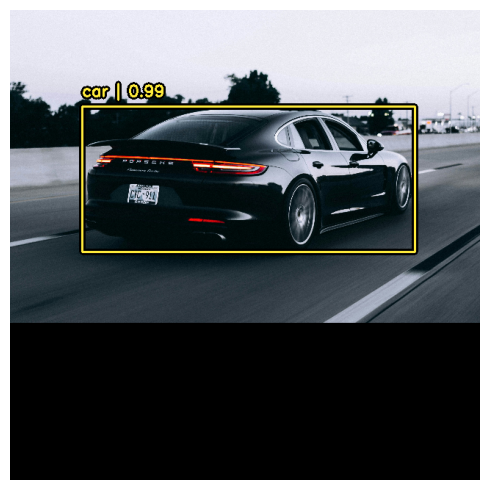

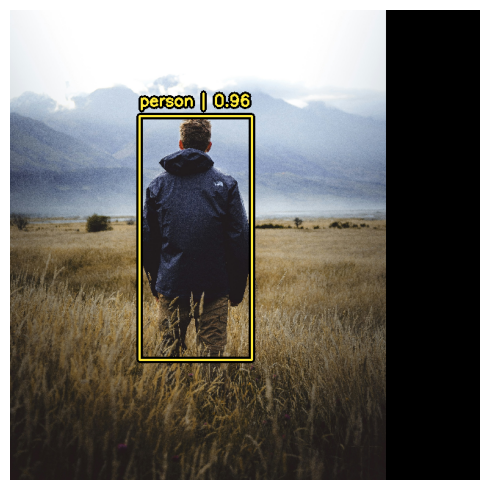

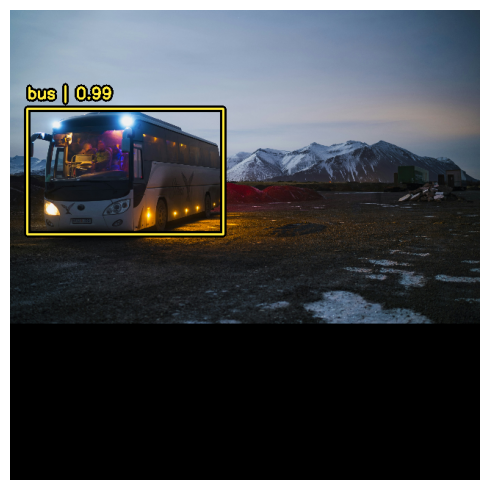

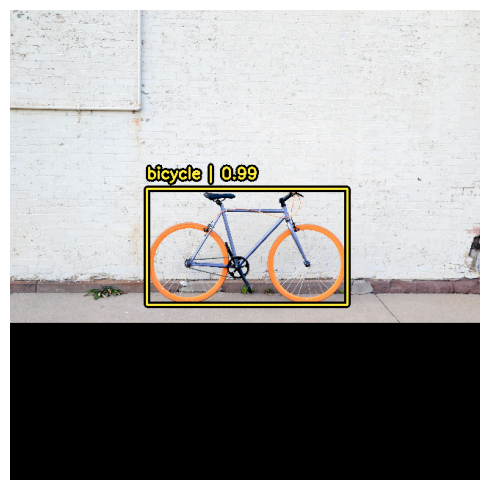

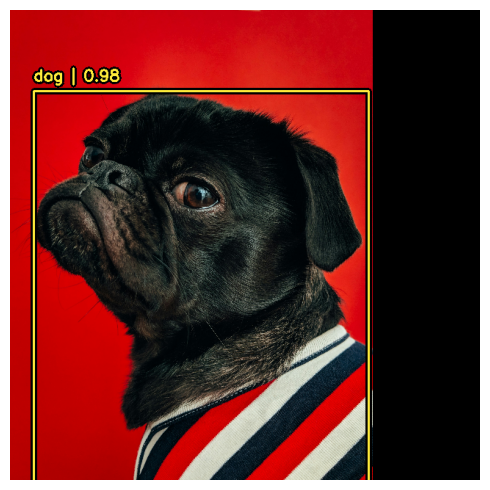

In [10]:
all_results = []

for idx, image in enumerate(images):
    print("=" * 60)
    print(f"Image {idx + 1}")

    resized_image, predictions = predict_image(model, image)
    detections = summarize_predictions(predictions, confidence_threshold=0.3)

    print("Detected objects:")
    for det in detections:
        print(f"- {det['label']} | confidence = {det['confidence']:.3f}")

    visualize_predictions(resized_image, predictions)

    all_results.append({
        "image_index": idx + 1,
        "detections": detections
    })

In [11]:
for item in all_results:
    print(f"\nImage {item['image_index']} summary:")
    if len(item["detections"]) == 0:
        print("No objects detected above threshold.")
    else:
        for det in item["detections"]:
            print(f"  {det['label']:12s}  score={det['confidence']:.3f}")


Image 1 summary:
  car           score=0.988

Image 2 summary:
  person        score=0.964

Image 3 summary:
  bus           score=0.990

Image 4 summary:
  bicycle       score=0.989

Image 5 summary:
  dog           score=0.984


This exercise utilized a pre-trained KerasCV YOLOv8 model to perform object detection on five Pascal VOC dataset classes. Test images were normalized and scaled to a padded 640*640 resolution to match the network's input shape while preserving their original aspect ratios. The resulting bounding boxes, labels, and confidence scores were visualized using automated overlays and systematically analyzed to audit true positive rates against missed or misclassified objects.